# **Receptor Comparison Experiment**

This notebook focuses on the impact of different heterogeneity maps on model fitting. The maps used are:
- T1w/T2w myelin map
- GABA-A receptor density map
- NMDA receptor density map  
- Dopamine receptor density map
- Norepinephrine receptor density map


**Each model has 5 parameters (w_EE, w_EE_slope, w_EI, w_EI_slope, G)**. The parameter ranges used for model fitting where as follows (can be found and changed in `scripts/optimization.py`):
- w_EI bias: [0.001, 3.0]
- w_EI coefficients: [0.001, 3.0] (per map)
- w_EE bias: [0.001, 3.0]
- w_EE coefficients: [0.001, 3.0] (per map)
- Global coupling (G): [0.001, 5.0]

The model was run for **35 iterations**, with **300 samples**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hbnm.io import Data
from hbnm.bnm import Bnm
from hbnm.model.utils import subdiag, fisher_z
from hbnm.analysis import SimulationAnalyzer
from scipy.stats import pearsonr
import os
import pandas as pd

# Set up matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300


In [2]:
# Define the simulations to analyze

# sims = ['baseline_heterogeneous', 'receptor_gaba_a_avg', 'receptor_nmda_avg', 'receptor_dopamine_avg', 'receptor_norepinephrine_avg']
# sims = ['baseline_homogeneous', 'baseline_heterogeneous', 'receptor_gaba_a_avg', 'baseline_nmda', 'receptor_dopamine_avg', 'receptor_norepinephrine_avg']
sims = ['receptor_dopamine_avg', 'dopamine_d1like_avg', 'dopamine_d2like_avg']

In [3]:
# Initialize data handler and analyzer
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)

input_dir = parent_path + '/data'
output_dir = parent_path + '/outputs'

data = Data(input_dir, output_dir)
analyzer = SimulationAnalyzer(data, verbose=True)

print(f"Target simulations: {sims}")

# Automatically detect available simulations
detected_sims = analyzer.detect_simulations()

# Use intersection of target and detected simulations
available_sims = [sim for sim in sims if sim in detected_sims]
print(f"Available simulations for analysis: {available_sims}")

Target simulations: ['receptor_dopamine_avg', 'dopamine_d1like_avg', 'dopamine_d2like_avg']
Detected 6 simulations: ['dopamine_d1like_avg', 'shuffled_norepinephrine_shuffled', 'shuffled_dopamine_shuffled', 'dopamine_d2like_avg', 'shuffled_gaba_shuffled', 'shuffled_nmda_shuffled']
Available simulations for analysis: ['dopamine_d1like_avg', 'dopamine_d2like_avg']


In [4]:
# Load all simulation data automatically
print("Loading all simulation data...")
all_simulation_data = analyzer.load_all_simulations(available_sims)

# Display summary of loaded data
print("\n" + "="*60)
print("DATA LOADING SUMMARY")
print("="*60)

for sim_name, sim_data in all_simulation_data.items():
    if sim_data['iterations']:
        print(f"\n{sim_name.upper()}:")
        print(f"  • Iterations: {len(sim_data['iterations'])} ({min(sim_data['iterations'])}-{max(sim_data['iterations'])})")
        print(f"  • Parameters: {sim_data['theta'][0].shape[0]}")
        print(f"  • Particles per iteration: {sim_data['theta'][0].shape[1]}")
        print(f"  • Final acceptance rate: {sim_data['acceptance_rate'][-1]:.1%}")
        print(f"  • Final epsilon: {sim_data['epsilon'][-1]:.4f}")
        print(f"  • Best distance achieved: {min([np.min(d) for d in sim_data['distances']]):.4f}")
    else:
        print(f"\n{sim_name.upper()}: No data loaded")

Loading all simulation data...

Loading simulation: dopamine_d1like_avg
Simulation 'dopamine_d1like_avg': found 47 iterations (1-47)
Loaded 47 iterations for dopamine_d1like_avg

Loading simulation: dopamine_d2like_avg
Simulation 'dopamine_d2like_avg': found 47 iterations (1-47)
Loaded 47 iterations for dopamine_d2like_avg

DATA LOADING SUMMARY

DOPAMINE_D1LIKE_AVG:
  • Iterations: 47 (1-47)
  • Parameters: 5
  • Particles per iteration: 100
  • Final acceptance rate: 1.3%
  • Final epsilon: 0.4685
  • Best distance achieved: 0.4596

DOPAMINE_D2LIKE_AVG:
  • Iterations: 47 (1-47)
  • Parameters: 5
  • Particles per iteration: 100
  • Final acceptance rate: 1.3%
  • Final epsilon: 0.4130
  • Best distance achieved: 0.4128


In [5]:
# Create summary report
print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY REPORT")
print("="*60)

summary_df = analyzer.create_summary_report(available_sims)
print(summary_df.to_string(index=False))

# Save summary to CSV
summary_df.to_csv(f"{output_dir}/receptor_simulation_summary.csv", index=False)
print(f"\nSummary saved to: {output_dir}/receptor_simulation_summary.csv")


COMPREHENSIVE SUMMARY REPORT
         Simulation  Iterations  Parameters Final_Acceptance_Rate Final_Epsilon Final_ESS Best_Distance Final_Distance Description
dopamine_d1like_avg          47           5                  1.3%        0.4685      57.4        0.4596         0.4596     Unknown
dopamine_d2like_avg          47           5                  1.3%        0.4130      46.3        0.4128         0.4128     Unknown

Summary saved to: /home/frank/HBNM/outputs/receptor_simulation_summary.csv



CREATING INDIVIDUAL SIMULATION PLOTS

Creating progress plot for dopamine_d1like_avg...


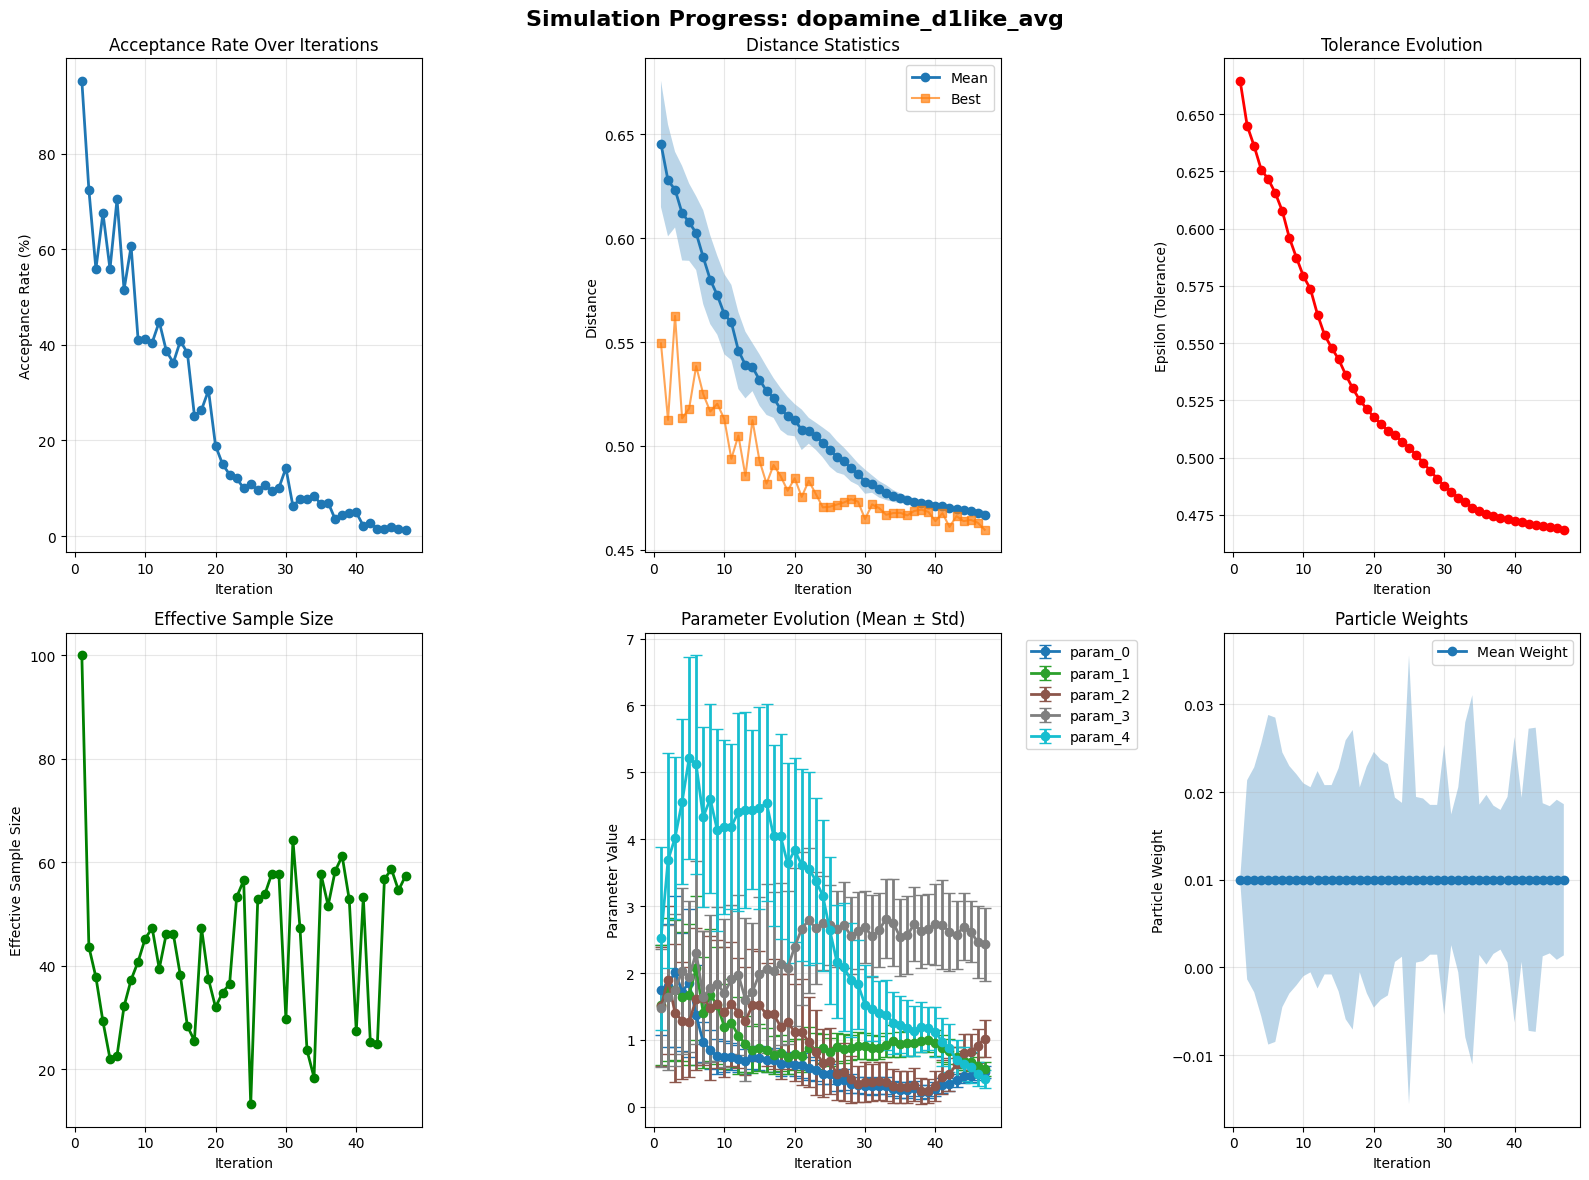


Creating progress plot for dopamine_d2like_avg...


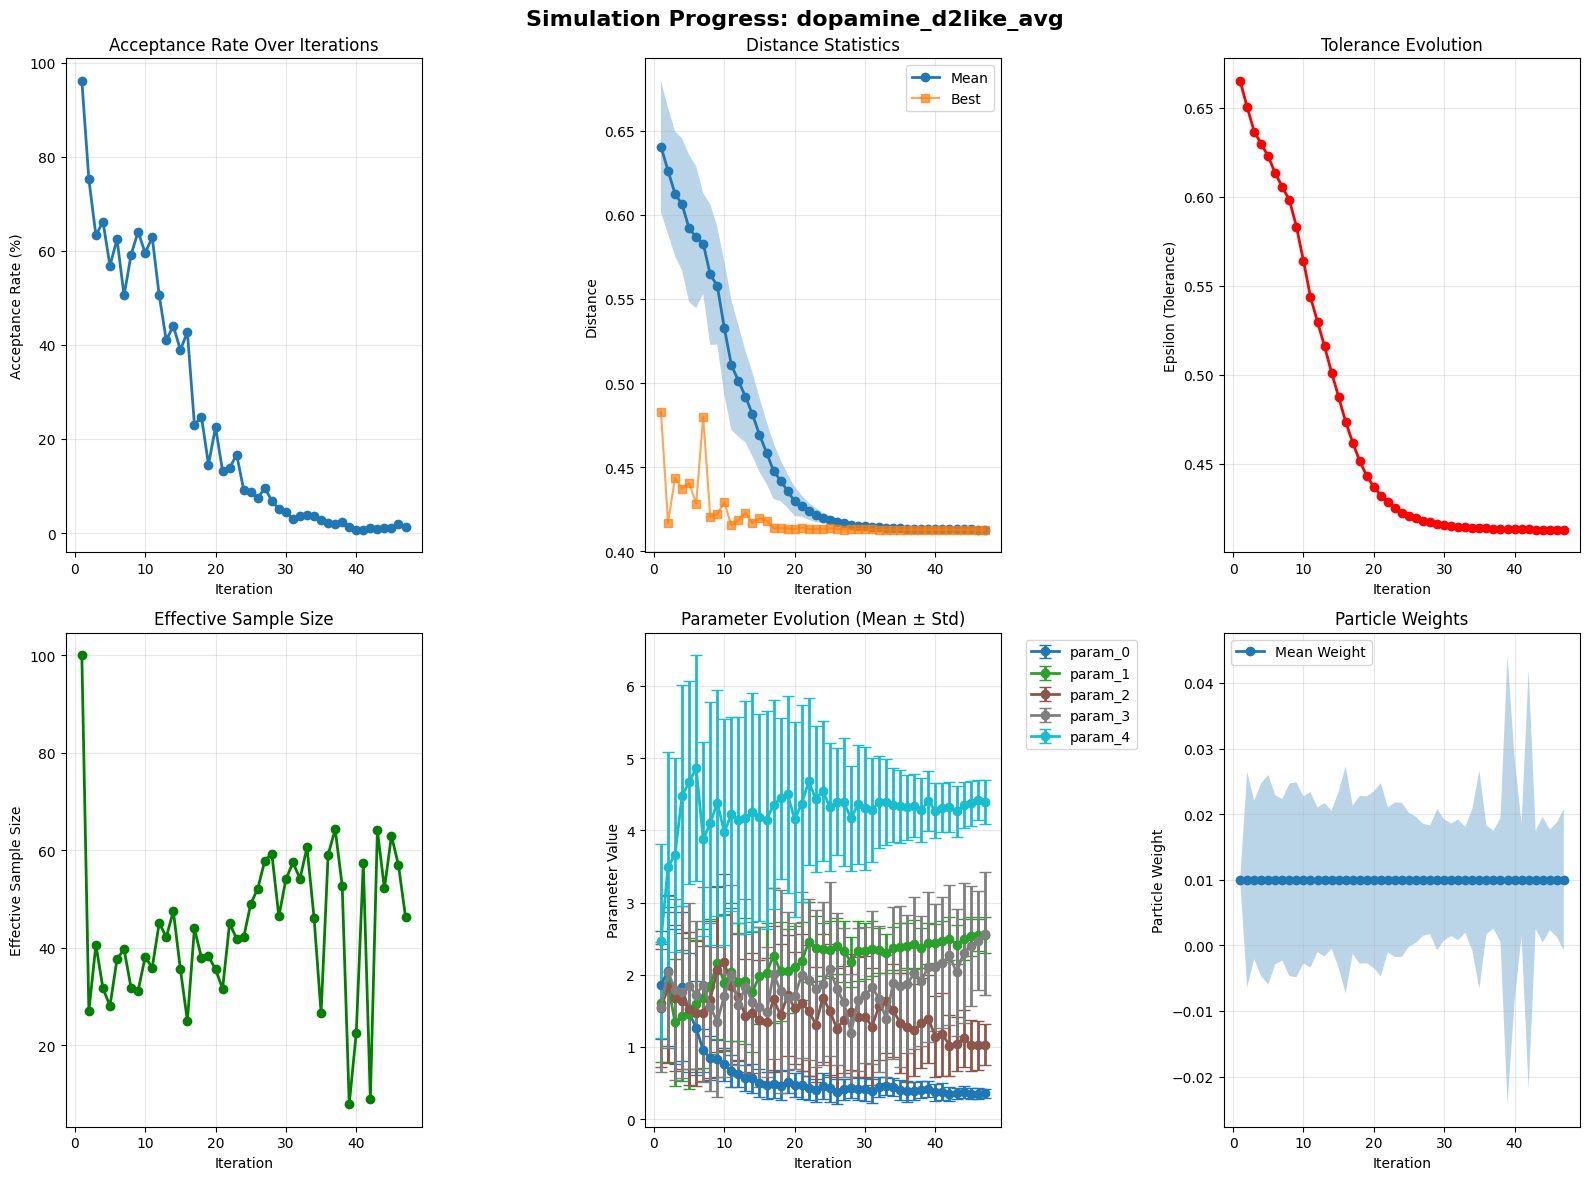

In [6]:
# Create individual simulation progress plots
print("\n" + "="*60)
print("CREATING INDIVIDUAL SIMULATION PLOTS")
print("="*60)

for sim_name in available_sims:
    print(f"\nCreating progress plot for {sim_name}...")
    fig = analyzer.plot_simulation_progress(sim_name, figsize=(16, 12))
    if fig is not None:
        plt.show()
        # You can save the figure if needed:
        # fig.savefig(f'{output_dir}/{sim_name}_progress.png', dpi=300, bbox_inches='tight')
    else:
        print(f"No plot could be created for {sim_name}")



CREATING COMPARATIVE ANALYSIS
Creating comparative plot across all simulations...


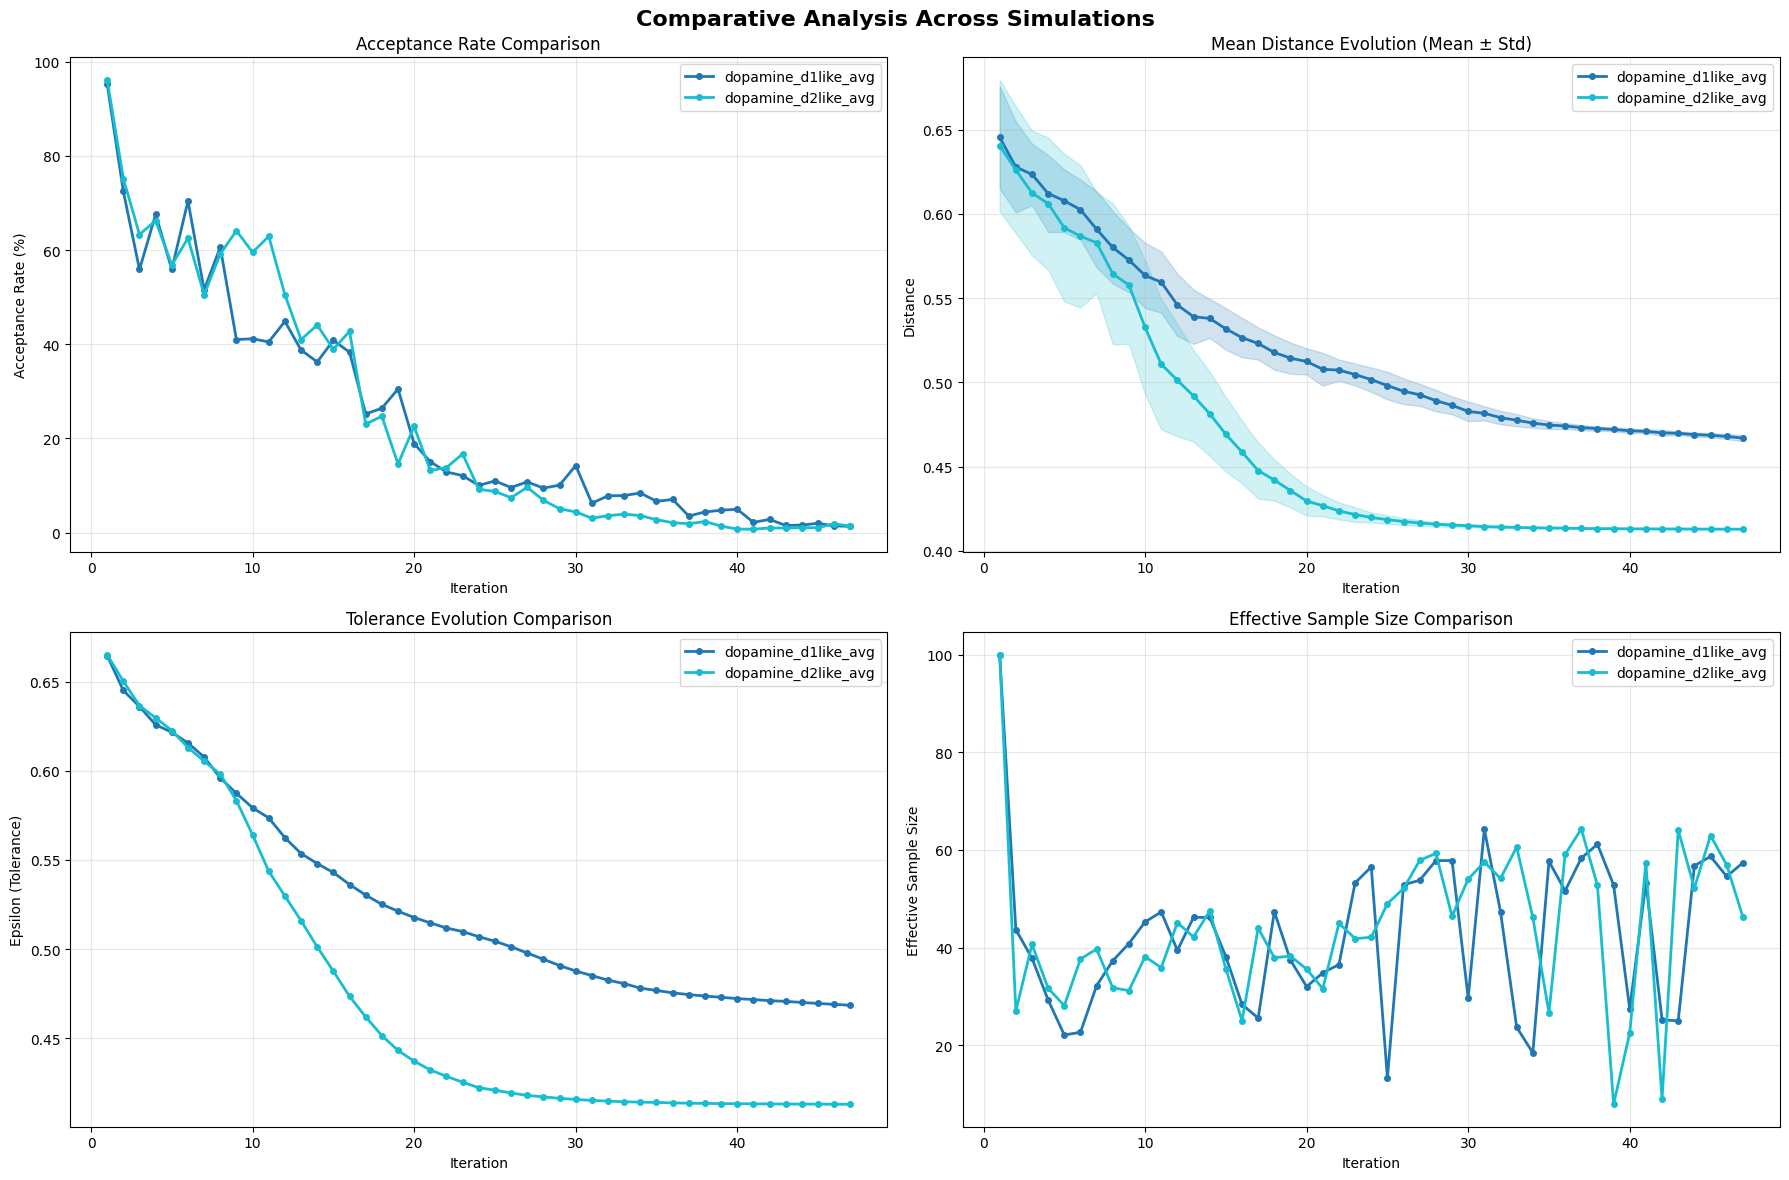

In [7]:
# Create comparative analysis across all simulations
if len(available_sims) > 1:
    print("\n" + "="*60)
    print("CREATING COMPARATIVE ANALYSIS")
    print("="*60)
    
    print("Creating comparative plot across all simulations...")
    fig = analyzer.plot_comparative_analysis(available_sims, figsize=(18, 12))
    if fig is not None:
        plt.show()
        # You can save the figure if needed:
        # fig.savefig(f'{output_dir}/comparative_analysis.png', dpi=300, bbox_inches='tight')
    else:
        print("No comparative plot could be created")
else:
    print("\nSkipping comparative analysis (need at least 2 simulations)")


In [8]:
# Save all plots and reports to a dedicated analysis folder
print("\n" + "="*60)
print("SAVING ALL PLOTS AND REPORTS")
print("="*60)

analysis_output_dir = f"{output_dir}/receptor_analysis_results"
analyzer.save_all_plots(analysis_output_dir, available_sims)

print(f"\nAll analysis results saved to: {analysis_output_dir}")
print("Files created:")
print("  • simulation_summary.csv - Summary statistics")
print("  • [simulation]_progress.png - Progress plots for each simulation")
print("  • [simulation]_parameters.png - Parameter evolution plots")
print("  • comparative_analysis.png - Cross-simulation comparison")



SAVING ALL PLOTS AND REPORTS


All plots and summary saved to: /home/frank/HBNM/outputs/receptor_analysis_results

All analysis results saved to: /home/frank/HBNM/outputs/receptor_analysis_results
Files created:
  • simulation_summary.csv - Summary statistics
  • [simulation]_progress.png - Progress plots for each simulation
  • [simulation]_parameters.png - Parameter evolution plots
  • comparative_analysis.png - Cross-simulation comparison
